In [ ]:
import marimo as mo

# Ingesta de colonias de Hermosillo (INEGI, DCAH 2025)

El INEGI publica las colonias como
información propia en el programa **Delimitación de Colonias y otros Asentamientos
Humanos (DCAH)**: polígonos por cada municipio.

## Objetivos del experimento
1. Descargar el DCAH 2025 con el cliente del INEGI, usando la fuente declarada en `params.yml`.
   El INEGI solo publica un paquete nacional con un ZIP por estado, así que bajamos
   únicamente el de Sonora.
2. Extraerlo en `data/interim/`.
3. Leer la capa de asentamientos y entender su sistema de coordenadas.
4. Filtrar Hermosillo y explorar qué trae: tipos de asentamiento, nombres, áreas.
5. Comprobar que las colonias que aparecen en los avisos de Agua de Hermosillo existen en la capa.

In [ ]:
from pathlib import Path
import re
import unicodedata
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from project_name.clients.http import HttpClient
from project_name.clients.inegi import InegiClient
from project_name.config import load_dataset_config, load_params
from project_name.policies.file import FilePolicy, OnExists

In [ ]:
params = load_params()
dataset = load_dataset_config(params, source="inegi", dataset="dcah_2025")

raw_file = Path(dataset["raw"]["directory"]) / dataset["raw"]["filename"]
interim_dir = Path(dataset["interim"]["directory"])
dataset

## Descarga
El paquete nacional pesa ~556 MB, pero solo necesitamos `26_sonora.zip` (~15 MB).
`download_zip_member` lee el índice del ZIP remoto (al final del archivo) y pide
al servidor únicamente los bytes de ese miembro, con peticiones HTTP por rango.
Una primera prueba bajando el paquete completo se cortó por timeout a los 492 MB.

La política `on_exists: skip` de `params.yml` omite la descarga si el archivo ya
está en `data/raw/`.

In [ ]:
policy = FilePolicy(on_exists=OnExists(dataset["download"]["on_exists"]))
client = InegiClient(http_client=HttpClient(file_policy=policy))

client.download_zip_member(
    url=dataset["url"],
    member=dataset["state_member"],
    destination=raw_file,
)
print(f"{raw_file} ({raw_file.stat().st_size / 1e6:.0f} MB)")

2026-09-18 15:19:45.730 | INFO     | project_name.clients.http:download_zip_member:56 - Skipping existing file: data/raw/inegi/dcah/dcah_2025_26_sonora.zip


data/raw/inegi/dcah/dcah_2025_26_sonora.zip (16 MB)


## Extracción
Validamos las rutas igual que el job de procesamiento del DENUE, para que un
nombre como `../../algo` no escriba fuera de `data/interim/` (Zip Slip).

In [ ]:
def safe_extract(archive: zipfile.ZipFile, destination: Path) -> None:
    # Rechaza cualquier miembro cuya ruta final quede fuera del destino.
    root = destination.resolve()
    for member in archive.infolist():
        target = (root / member.filename).resolve()
        if root not in target.parents and target != root:
            raise ValueError(f"Ruta insegura en el zip: {member.filename}")
    archive.extractall(destination)

In [ ]:
interim_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(raw_file) as state_archive:
    safe_extract(state_archive, interim_dir)

for extracted in sorted(interim_dir.rglob("*")):
    if extracted.is_file():
        print(extracted.relative_to(interim_dir))

catalogos/asentamientos_humanos.csv
catalogos/asentamientos_humanos.pdf
catalogos/contenido.pdf
catalogos/contenido.txt
conjunto_de_datos/26as.dbf
conjunto_de_datos/26as.prj
conjunto_de_datos/26as.sbn
conjunto_de_datos/26as.sbx
conjunto_de_datos/26as.shp
conjunto_de_datos/26as.shx
metadatos/delimitacion_de_colonias_y_otros_asentamientos_humanos_2025_26_sonora.txt
metadatos/delimitacion_de_colonias_y_otros_asentamientos_humanos_2025_26_sonora.xml
metadatos/metadatos_dcah_2025_26_sonora.txt


## Metadatos y catálogo
Cada archivo del paquete usa su propia codificación: los metadatos vienen en
ISO-8859-1 (como el resto de los productos del INEGI), mientras que el catálogo
CSV y la capa `.shp` están en UTF-8.

In [ ]:
metadata_file = next((interim_dir / "metadatos").glob("metadatos_dcah_*.txt"))
metadata_text = metadata_file.read_text(encoding="latin-1")
print(metadata_text[:1500])

Title: Delimitación de colonias y otros asentamientos humanos 2025 (26-Sonora).


Descripción: La Delimitación de colonias y otros asentamientos humanos 2025 (26-Sonora), es un producto resultado de un trabajo conjunto entre las autoridades municipales de los Estados de la República Mexicana y el Instituto Nacional de Estadística y Geografía (INEGI).

Conforme a los artículos 115, fracción V, incisos a) y d) Constitucional, 11, fracción III y 59 de la Ley General de Asentamientos Humanos, Ordenamiento Territorial y Desarrollo Urbano (LGAHOTDU), corresponde a los Municipios formular, aprobar y administrar la Zonificación de los Centros de Población ubicados en su territorio, y en ese sentido, son responsables de identificar y delimitar las áreas y asentamientos humanos que los integran.

Así, la conformación de la delimitación de asentamientos humanos se genera a partir de la información proporcionada y validada por las autoridades municipales, quienes tienen competencia en la materia. 

In [ ]:
# El catálogo trae los mismos atributos que la capa, sin geometría. Ojo: aunque
# viene dentro del ZIP de Sonora, es el catálogo nacional, y a diferencia de los
# metadatos está en UTF-8.
catalog = pd.read_csv(interim_dir / "catalogos" / "asentamientos_humanos.csv", dtype=str)
print(catalog.shape)
print(catalog["cve_ent"].nunique(), "entidades en el catálogo")
catalog.head()

(79775, 10)
32 entidades en el catálogo


,cvegeo,cve_ent,cve_mun,cve_loc,cve_asen,cp,fecha_act,institucio,nom_asen,tipo
0,0100100010001,01,001,0001,0001,20263,11/2023,SECRETARÍA DE DESARROLLO URBANO DEL MUNICIPIO DE AGUASCALIENTES,AGUA CLARA,FRACCIONAMIENTO
1,0100100010002,01,001,0001,0002,20159,11/2023,SECRETARÍA DE DESARROLLO URBANO DEL MUNICIPIO DE AGUASCALIENTES,ALIANZA FERROCARRILERA,FRACCIONAMIENTO
2,0100100010003,01,001,0001,0003,20040,11/2023,SECRETARÍA DE DESARROLLO URBANO DEL MUNICIPIO DE AGUASCALIENTES,ALTAVISTA,COLONIA
3,0100100010004,01,001,0001,0004,20230,11/2023,SECRETARÍA DE DESARROLLO URBANO DEL MUNICIPIO DE AGUASCALIENTES,LAS AMERICAS,FRACCIONAMIENTO
4,0100100010005,01,001,0001,0005,20020,11/2023,SECRETARÍA DE DESARROLLO URBANO DEL MUNICIPIO DE AGUASCALIENTES,LAS ARBOLEDAS,FRACCIONAMIENTO


## Lectura de la capa de asentamientos
La capa `26as` (asentamientos de Sonora) usa **EPSG:6372**: Cónica Conforme de
Lambert sobre ITRF2008, en **metros**. Es la proyección oficial del INEGI para
todo México y sirve para calcular áreas; para mapas web o para cruzar con
latitud/longitud hay que convertir a **EPSG:4326**.

In [ ]:
settlements = gpd.read_file(interim_dir / "conjunto_de_datos" / "26as.shp")

print(settlements.shape)
print(settlements.crs.name, "| EPSG:", settlements.crs.to_epsg())
settlements.head()

(2699, 11)
Mexico ITRF2008 / LCC | EPSG: 6372


,cvegeo,cve_ent,cve_mun,cve_loc,cve_asen,cp,fecha_act,institucio,nom_asen,tipo,geometry
0,2600100010001,26,001,0001,0001,00000,11/2023,"SINDICATURA MUNICIPAL DE ACONCHI, SONORA",CENTRO,COLONIA,"POLYGON ((1704471.071 1995990.221, 1704497.18 1995952.559, 1704526.326 1995961.35, 1704557.273 1995951.573, 1704573.968 1995949.544, 1704626.351 1995948.783, 1704676.502 1995949.777, 1704727.692 1995952.34, 1704739.539 1995952.501, 1704833.323 1995952.489, 1704931.421 1995954.564, 1704942.249 1995956.346, 1705041.328 1995952.042, 1705041.37 1995878.959, 1705044.597 1995833.27, 1705046.105 1995764.815, 1705055.658 1995670.495, 1705063.006 1995586.496, 1705071.207 1995500.865, 1705080.756 1995428.824, 1705092.914 1995403.981, 1705097.279 1995374.215, 1705132.33 1995292.288, 1705129.759 1995290.794, 1705102.659 1995275.052, 1705020.857 1995179.462, 1705012.816 1995165.891, 1705011.834 1995164.233, 1705006.467 1995155.179, 1704969.7 1995139.888, 1704944.55 1995135.896, 1704936.515 1995134.554, 1704929.125 1995120.427, 1704935.482 1995051.069, 1704900.682 1995041.383, 1704906.813 1995006.039, 1704908.673 1994995.319, 1704848.061 1994960.442, 1704837.896 1994956.386, 1704842.117 1994945.523, 1704842.794 1994943.779, 1704814.596 1994915.584, 1704811.791 1994899.789, 1704811.325 1994897.162, 1704813.988 1994872.901, 1704825.357 1994842.851, 1704825.933 1994824.443, 1704825.937 1994824.345, 1704823.217 1994807.404, 1704817.424 1994797.03, 1704804.905 1994790.981, 1704784.948 1994791.725, 1704769.466 1994746.443, 1704725.721 1994760.911, 1704723.625 1994761.604, 1704693.635 1994771.523, 1704706.457 1994811.829, 1704691.411 1994841.288, 1704688.09 1994864.927, 1704685.097 1994908.677, 1704645.392 1994947.872, 1704632.446 1994974.28, 1704624.174 1994986.783, 1704622.192 1994997.632, 1704589.09 1994985.861, 1704542.547 1995033.656, 1704513.88 1995082.739, 1704516.01 1995110.579, 1704519.176 1995131.455, 1704519.396 1995141.475, 1704517.746 1995154.572, 1704515.382 1995172.835, 1704521.42 1995194.436, 1704539.065 1995244.457, 1704547.992 1995305.709, 1704548.839 1995351.563, 1704545.441 1995404.084, 1704540.449 1995420.708, 1704544.03 1995437.316, 1704547.599 1995448.514, 1704546.998 1995464.902, 1704541.648 1995480.12, 1704522.19 1995515.874, 1704497.816 1995559.616, 1704487.767 1995577.65, 1704468.024 1995564.614, 1704413.421 1995660.596, 1704435.997 1995669.731, 1704398.569 1995723.416, 1704391.309 1995739.41, 1704386.831 1995761.09, 1704393.445 1995788.489, 1704356.573 1995795.188, 1704365.475 1995895.205, 1704353.925 1995937.424, 1704400.246 1995959.702, 1704471.071 1995990.221))"
1,2600100010002,26,001,0001,0002,00000,11/2023,"SINDICATURA MUNICIPAL DE ACONCHI, SONORA",NORTE,COLONIA,"POLYGON ((1704471.071 1995990.221, 1704494.725 1995999.839, 1704530.822 1996018.598, 1704580.104 1996044.852, 1704631.083 1996067.795, 1704650.265 1996076.457, 1704668.725 1996086.459, 1704703.852 1996111.186, 1704731.043 1996127.019, 1704746.035 1996133.681, 1704773.044 1996133.513, 1704796.465 1996132.402, 1704818.442 1996127.077, 1704846.768 1996117.636, 1704878.011 1996110.923, 1704919.927 1996101.659, 1704943.858 1996079.484, 1704967.196 1996061.226, 1704995.874 1996043.225, 1705020.521 1996027.213, 1705035.957 1996020.883, 1705052.873 1996015.755, 1705092.511 1996002.083, 1705119.677 1996003.283, 1705146.287 1996013.455, 1705178.284 1996012.516, 1705214.479 1996003.085, 1705253.59 1996003.559, 1705285.408 1996010.262, 1705305.393 1996012.323, 1705321.199 1996013.235, 1705374.467 1996009.089, 1705375.276 1995954.449, 1705340.688 1995949.776, 1705291.666 1995942.853, 1705280.271 1995941.114, 1705234.677 1995942.694, 1705088.626 1995951.027, 1705041.328 1995952.042, 1704942.249 1995956.346, 1704931.421 1995954.564, 1704833.323 1995952.489, 1704739.539 1995952.501, 1704727.692 1995952.34, 1704676.502 1995949.777, 1704626.351 1995948.783, 1704573.968 1995949.544, 1704557.273 1995951.573, 1704526.326 1995961.35, 1704497.18 1995952.559, 1704471.071 1995990.221))"
2,2

## Hermosillo
Filtramos por clave de municipio (`030`) en vez de por nombre, y renombramos las
columnas a inglés. La localidad `0001` es la ciudad; `0137` es Bahía de Kino y
`0343`, Miguel Alemán.

In [ ]:
HERMOSILLO_MUNICIPALITY = "030"

columns = {
    "cvegeo": "geo_code",
    "cve_ent": "state_code",
    "cve_mun": "municipality_code",
    "cve_loc": "locality_code",
    "cve_asen": "settlement_code",
    "cp": "postal_code",
    "fecha_act": "updated_at",
    "institucio": "source_institution",
    "nom_asen": "settlement_name",
    "tipo": "settlement_type",
    "geometry": "geometry",
}

hermosillo = (
    settlements[settlements["cve_mun"] == HERMOSILLO_MUNICIPALITY]
    .rename(columns=columns)
    .set_geometry("geometry")
)
# Área en km², válida porque EPSG:6372 está en metros.
hermosillo["area_km2"] = hermosillo.area / 1e6

print(f"{len(hermosillo)} asentamientos en Hermosillo")
hermosillo.drop(columns="geometry").head()

783 asentamientos en Hermosillo


,geo_code,state_code,municipality_code,locality_code,settlement_code,postal_code,updated_at,source_institution,settlement_name,settlement_type,area_km2
1071,2603000010001,26,030,0001,0001,83290,11/2025,"DIRECCIÓN DE CATASTRO, HERMOSILLO",Y Griega,BARRIO,0.587873
1072,2603000010002,26,030,0001,0002,83170,11/2025,"DIRECCIÓN DE CATASTRO, HERMOSILLO",22 de Septiembre,COLONIA,0.091522
1073,2603000010003,26,030,0001,0003,83010,11/2025,"DIRECCIÓN DE CATASTRO, HERMOSILLO",5 de Mayo,COLONIA,0.412143
1074,2603000010004,26,030,0001,0004,83295,11/2025,"DIRECCIÓN DE CATASTRO, HERMOSILLO",Adolfo de la Huerta,COLONIA,0.170764
1075,2603000010005,26,030,0001,0005,83170,11/2025,"DIRECCIÓN DE CATASTRO, HERMOSILLO",Adolfo López Mateos,COLONIA,0.663419


In [ ]:
# Cuántos asentamientos por localidad, por tipo y por fecha de actualización.
print(hermosillo["locality_code"].value_counts().to_string(), end="\n\n")
print(hermosillo["settlement_type"].value_counts().to_string(), end="\n\n")
print(hermosillo[["updated_at", "source_institution"]].value_counts().to_string())

locality_code
0001    762
0137     12
0343      9

settlement_type
FRACCIONAMIENTO      398
COLONIA              300
RESIDENCIAL           33
PRIVADA               19
PARQUE INDUSTRIAL     11
AMPLIACIÓN             7
BARRIO                 4
NINGUNO                4
CONDOMINIO             4
ZONA MILITAR           1
SECTOR                 1
ZONA INDUSTRIAL        1

updated_at  source_institution               
11/2025     DIRECCIÓN DE CATASTRO, HERMOSILLO    762
11/2022     DIRECCIÓN DE CATASTRO, HERMOSILLO     21


In [ ]:
# El código postal "00000" indica que el municipio no lo reportó.
missing_postal_code = (hermosillo["postal_code"] == "00000").sum()
print(f"Sin código postal: {missing_postal_code} de {len(hermosillo)}")

hermosillo["area_km2"].describe()

Sin código postal: 20 de 783


,area_km2
count,783.000000
mean,0.178442
std,0.331161
min,0.000899
25%,0.039906
50%,0.086750
75%,0.178922
max,4.493670


## ¿Aparecen las colonias de los avisos?
Los avisos de Agua de Hermosillo mencionan colonias con variaciones de acentos
y mayúsculas ("MISION DEL ARCO", "Misión del Arco"). Normalizamos los nombres
(sin acentos, en mayúsculas, sin espacios repetidos) y buscamos algunas colonias
tomadas de publicaciones reales.

In [ ]:
def normalize_name(name: str) -> str:
    # Quita acentos y puntuación, y unifica mayúsculas y espacios para comparar nombres.
    ascii_name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode()
    return " ".join(re.sub(r"[^A-Za-z0-9 ]", " ", ascii_name).upper().split())

In [ ]:
city = hermosillo[hermosillo["locality_code"] == "0001"].copy()
city["settlement_key"] = city["settlement_name"].map(normalize_name)

# Colonias mencionadas en avisos de Facebook (texto y OCR de las imágenes).
mentioned = [
    "Bachoco",
    "MISION DEL ARCO",
    "Villa de Seris",
    "Pueblitos",
    "Olivos",
    "Castelina",
    "Nuevo Hermosillo",
    "Altares",
    "Sahuaro",
    "Modelo",
]

matches = pd.DataFrame(
    [
        {
            "mentioned": name,
            "exact_match": (city["settlement_key"] == normalize_name(name)).any(),
            "partial_matches": city.loc[
                city["settlement_key"].str.contains(normalize_name(name), regex=False),
                "settlement_name",
            ].tolist(),
        }
        for name in mentioned
    ]
)
matches

,mentioned,exact_match,partial_matches
0,Bachoco,True,[Bachoco]
1,MISION DEL ARCO,True,[Misión del Arco]
2,Villa de Seris,True,[Villa de Seris]
3,Pueblitos,False,"[Pueblitos Sección los Álamos, Pueblitos Cerrada Guarijios, Pueblitos Cerrada Kikapú, Pueblitos Cerrada Pápagos, Pueblitos Cerrada Kukapú]"
4,Olivos,False,"[Cuatro Olivos, Los Olivos, Margaritas Olivos]"
5,Castelina,True,[Castelina]
6,Nuevo Hermosillo,True,[Nuevo Hermosillo]
7,Altares,True,"[Altares, Altares II, Altares]"
8,Sahuaro,True,"[Sahuaro, Sahuaro INDECO, Sahuaro Final, Sahuaro Final, Nuevo Sahuaro]"
9,Modelo,True,[Modelo]


Las coincidencias exactas no bastan: algunas colonias vienen partidas en secciones
("Pueblitos Sección los Álamos", "Sahuaro Final") y otras comparten palabra con
colonias distintas ("Los Olivos" y "Cuatro Olivos"). Al emparejar los avisos
habrá que decidir la granularidad: sección exacta o colonia "madre".

## Mapa de la ciudad

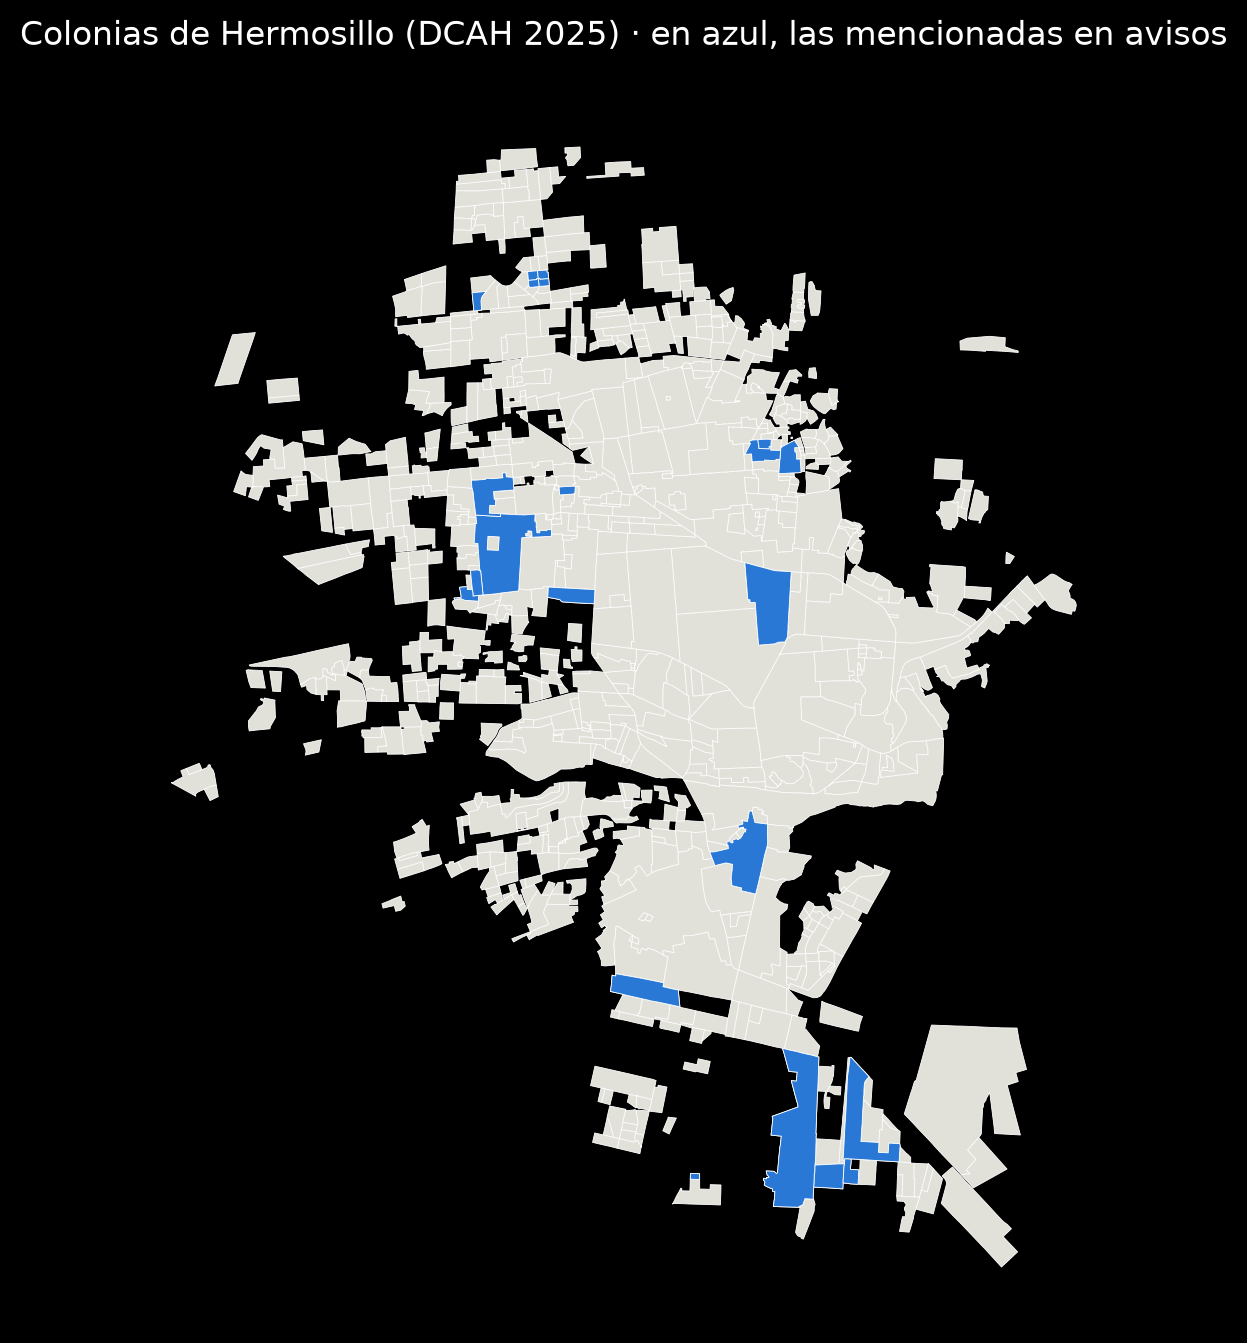

In [ ]:
mentioned_keys = [normalize_name(name) for name in mentioned]
is_mentioned = city["settlement_key"].apply(
    lambda key: any(mentioned_key in key for mentioned_key in mentioned_keys)
)

fig_map, ax_map = plt.subplots(figsize=(8, 8))
city.plot(ax=ax_map, color="#e1e0d9", edgecolor="#ffffff", linewidth=0.3)
city[is_mentioned].plot(ax=ax_map, color="#2a78d6", edgecolor="#ffffff", linewidth=0.3)
ax_map.set_title("Colonias de Hermosillo (DCAH 2025) · en azul, las mencionadas en avisos")
ax_map.set_axis_off()
fig_map

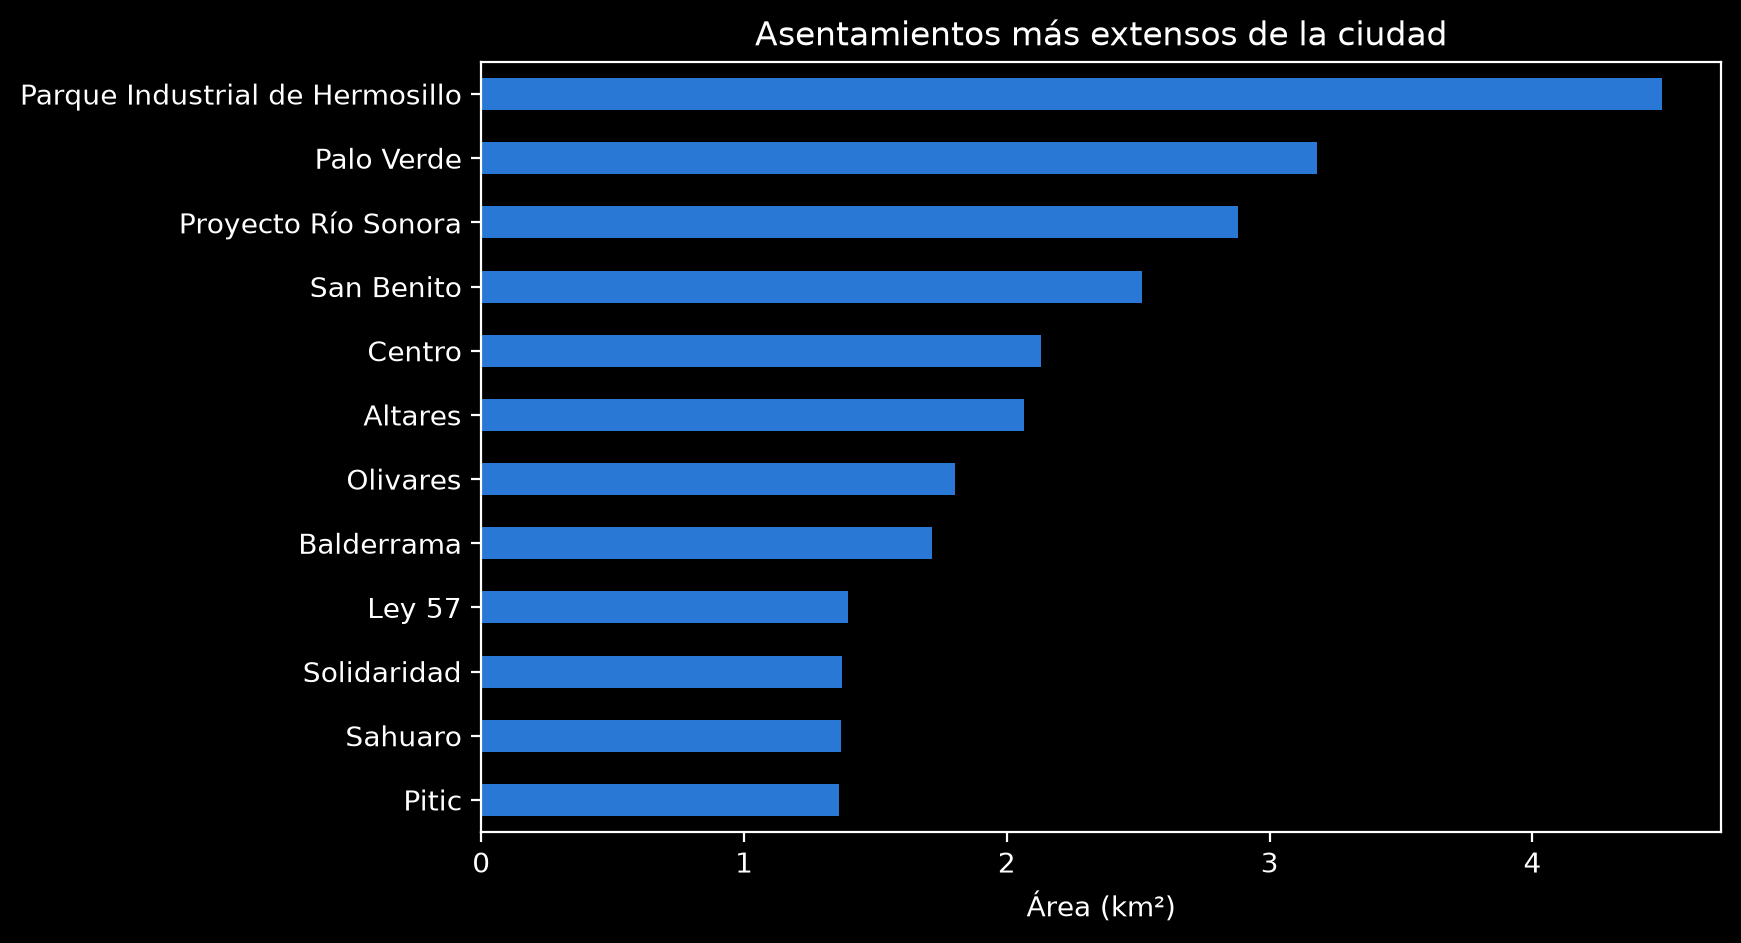

In [ ]:
# Las colonias más grandes suelen ser parques industriales o zonas en desarrollo;
# conviene tenerlas ubicadas antes de normalizar quejas por área.
largest = city.nlargest(12, "area_km2").set_index("settlement_name")["area_km2"].sort_values()

fig_area, ax_area = plt.subplots(figsize=(8, 5))
largest.plot.barh(ax=ax_area, color="#2a78d6")
ax_area.set_xlabel("Área (km²)")
ax_area.set_ylabel("")
ax_area.set_title("Asentamientos más extensos de la ciudad")
fig_area

## Hallazgos y siguientes pasos
- El DCAH 2025 cubre Hermosillo con polígonos de colonias actualizados por
  Catastro municipal: es la capa base para el mapa del tablero.
- Los nombres requieren normalización y reglas para secciones y etapas antes de
  cruzarlos con los avisos de Facebook.
- Los avisos casi nunca nombran colonias sino cruces de calles; ubicarlos es el
  tema de `02-job-ingestion-calles-mg-marimo.py`, que usa las colonias extraídas aquí.
- Siguiente: convertir esta exploración en un job (`ingest_dcah_job`), y cruzar
  los polígonos con las AGEB del Marco Geoestadístico para obtener la población
  por colonia y normalizar las afectaciones por habitante.